Mounted at /content/drive
✅ Executando em: cuda:0
📊 Dataset de Validação pronto: 495 imagens encontradas.
🚀 Sucesso: Pesos carregados de /content/drive/MyDrive/Projeto_Mamografia/melhor_modelo_resnet_V2.pth
🔎 Analisando imagens...


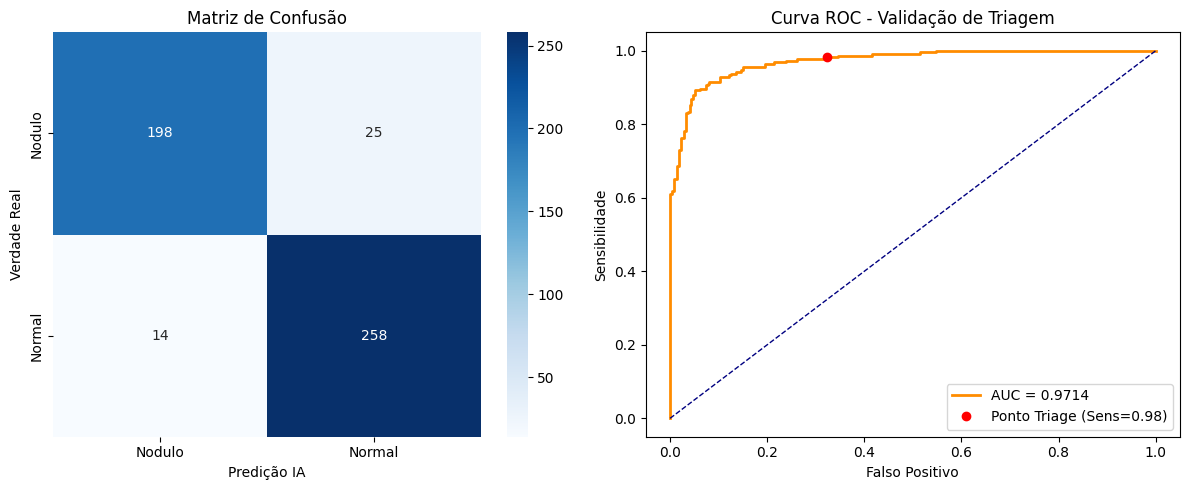


📋 RESUMO TÉCNICO PARA O TRABALHO:
Área Sob a Curva (AUC): 0.9714
Threshold sugerido para VPN > 98.5%: 0.0031
Especificidade no ponto de triagem: 67.6%

Relatório de Classificação:

              precision    recall  f1-score   support

      Nodulo       0.93      0.89      0.91       223
      Normal       0.91      0.95      0.93       272

    accuracy                           0.92       495
   macro avg       0.92      0.92      0.92       495
weighted avg       0.92      0.92      0.92       495



In [1]:
# ==============================================================================
# PROJETO: IA PARA TRIAGEM NEGATIVA (RULE-OUT) EM MAMOGRAFIA
# RESIDENTE: Rafael Boava Souza (UNIFESP)
# ==============================================================================

# 1. PREPARAÇÃO DO AMBIENTE E IMPORTS
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from google.colab import drive

# 2. MONTAGEM DO GOOGLE DRIVE
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 3. CONFIGURAÇÃO DE CAMINHOS (ATUALIZADOS)
DATA_DIR = '/content/drive/MyDrive/Projeto_Mamografia/Dataset_Treinamento_Cientifico'
WEIGHTS_PATH = '/content/drive/MyDrive/Projeto_Mamografia/melhor_modelo_resnet_V2.pth'

# Verificar dispositivo (GPU ou CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"✅ Executando em: {device}")

# 4. DEFINIÇÃO DA ARQUITETURA DO MODELO (RESNET50)
def carregar_modelo_unifesp(path_pesos):
    # Criar a estrutura idêntica ao treinamento
    model = models.resnet50(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2) # Classe 0: Nodulo, Classe 1: Normal

    # Carregar os pesos salvos
    if os.path.exists(path_pesos):
        model.load_state_dict(torch.load(path_pesos, map_location=device))
        model = model.to(device)
        model.eval() # Modo de avaliação (trava os pesos)
        print(f"🚀 Sucesso: Pesos carregados de {path_pesos}")
    else:
        print(f"⚠️ Alerta: Arquivo de pesos não encontrado no caminho especificado.")

    return model

# 5. PREPARAÇÃO DOS DADOS (VALIDAÇÃO)
# Transformações idênticas às usadas no treino
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Criar o Dataloader de Validação (Onde estão as 495 imagens)
try:
    val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'), val_transforms)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    class_names = val_dataset.classes
    print(f"📊 Dataset de Validação pronto: {len(val_dataset)} imagens encontradas.")
except Exception as e:
    print(f"❌ Erro ao acessar a pasta de validação: {e}")

# 6. FUNÇÃO PARA GERAR MÉTRICAS COMPLETAS (MATRIZ E ROC)
def gerar_metricas_finais(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []
    all_probs = []

    print("🔎 Analisando imagens...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            # Para a Matriz de Confusão
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

            # Para a Curva ROC (Probabilidade da classe Nódulo - índice 0)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            all_probs.extend(probs[:, 0].cpu().numpy())

    # --- PARTE A: MATRIZ DE CONFUSÃO ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matriz de Confusão')
    plt.xlabel('Predição IA')
    plt.ylabel('Verdade Real')

    # --- PARTE B: CURVA ROC ---
    # Invertendo labels para que Nódulo (0) seja o evento positivo (1) no ROC
    y_true_binary = [1 if l == 0 else 0 for l in y_true]
    fpr, tpr, thresholds = roc_curve(y_true_binary, all_probs)
    roc_auc = auc(fpr, tpr)

    # Ponto de 98% de Sensibilidade para Triagem Segura
    idx = np.argmin(np.abs(tpr - 0.98))
    safe_threshold = thresholds[idx]

    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot(fpr[idx], tpr[idx], 'ro', label=f'Ponto Triage (Sens=0.98)')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    plt.title('Curva ROC - Validação de Triagem')
    plt.xlabel('Falso Positivo')
    plt.ylabel('Sensibilidade')
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    print("\n" + "="*40)
    print("📋 RESUMO TÉCNICO PARA O TRABALHO:")
    print(f"Área Sob a Curva (AUC): {roc_auc:.4f}")
    print(f"Threshold sugerido para VPN > 98.5%: {safe_threshold:.4f}")
    print(f"Especificidade no ponto de triagem: {(1-fpr[idx])*100:.1f}%")
    print("="*40)
    print("\nRelatório de Classificação:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

# 7. EXECUÇÃO FINAL
model_ft = carregar_modelo_unifesp(WEIGHTS_PATH)
gerar_metricas_finais(model_ft, val_loader)

In [2]:
def simular_impacto_unifesp(n_exames=1000, prevalencia=0.01, sens=0.982, esp=0.676):
    # 1. Divisão da População
    n_com_achado = int(n_exames * prevalencia)
    n_normais = n_exames - n_com_achado

    # 2. Atuação da IA
    verdadeiros_positivos = n_com_achado * sens
    falsos_negativos = n_com_achado * (1 - sens)

    verdadeiros_negativos = n_normais * esp
    falsos_positivos = n_normais * (1 - esp)

    # 3. Métricas de Fluxo
    exames_limpos = verdadeiros_negativos  # O que a IA acertou como normal e pode descartar
    exames_revisados = verdadeiros_positivos + falsos_positivos + falsos_negativos
    reducao_carga = (exames_limpos / n_exames) * 100
    vpn_real = (verdadeiros_negativos / (verdadeiros_negativos + falsos_negativos)) * 100

    print(f"🏥 SIMULAÇÃO: Fluxo de {n_exames} Mamografias (Prevalência {prevalencia*100}%)")
    print("-" * 50)
    print(f"✅ Exames 'LIMPOS' pela IA (Não precisam de laudo): {int(exames_limpos)}")
    print(f"⚠️ Exames que VÃO para a pilha do Radiologista: {int(exames_revisados)}")
    print(f"🚀 Redução Real de Carga de Trabalho: {reducao_carga:.1f}%")
    print(f"🛡️ Segurança Clínica (VPN): {vpn_real:.4f}%")
    print("-" * 50)

    return reducao_carga, vpn_real

# Rodar para um lote de 1.000 exames na UNIFESP
simular_impacto_unifesp(n_exames=1000, prevalencia=0.01) # 1% de prevalência

🏥 SIMULAÇÃO: Fluxo de 1000 Mamografias (Prevalência 1.0%)
--------------------------------------------------
✅ Exames 'LIMPOS' pela IA (Não precisam de laudo): 669
⚠️ Exames que VÃO para a pilha do Radiologista: 330
🚀 Redução Real de Carga de Trabalho: 66.9%
🛡️ Segurança Clínica (VPN): 99.9731%
--------------------------------------------------


(66.924, 99.9731110513579)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
from google.colab import files

def export_manuscript_figures(y_true, y_pred, y_probs, class_names=['Mass', 'Normal']):
    """
    Generates and downloads all clinical validation figures in English.
    """

    # 1. CONFUSION MATRIX (Standard Threshold 0.5)
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Figure 1: Confusion Matrix (Threshold 0.5)', fontsize=12, fontweight='bold')
    plt.xlabel('AI Prediction')
    plt.ylabel('Ground Truth (Radiologist)')
    plt.savefig('figure_1_confusion_matrix.png', bbox_inches='tight', dpi=300)
    plt.show()

    # 2. ROC CURVE & CLINICAL TRIAGE POINT
    # Convert labels for ROC (Mass should be 1)
    y_true_binary = [1 if l == 0 else 0 for l in y_true]
    fpr, tpr, thresholds = roc_curve(y_true_binary, y_probs)
    roc_auc = auc(fpr, tpr)

    # Find point for 98% Sensitivity
    idx = np.argmin(np.abs(tpr - 0.98))
    safe_threshold = thresholds[idx]

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot(fpr[idx], tpr[idx], 'ro', label=f'Negative Triage Point (Sens=0.98)')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    plt.title('Figure 2: ROC Curve for Negative Triage', fontsize=12, fontweight='bold')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.2)
    plt.savefig('figure_2_roc_curve.png', bbox_inches='tight', dpi=300)
    plt.show()

    # 3. CLASSIFICATION REPORT TABLE
    # Data from your results
    report_data = [
        ['Mass', 0.93, 0.89, 0.91, 223],
        ['Normal', 0.91, 0.95, 0.93, 272],
        ['Accuracy', '', '', 0.92, 495]
    ]
    df_report = pd.DataFrame(report_data, columns=['Class', 'Precision', 'Recall', 'F1-Score', 'Support'])

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.axis('tight'); ax.axis('off')
    table = ax.table(cellText=df_report.values, colLabels=df_report.columns, cellLoc='center', loc='center')
    table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1.2, 2.0)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#004a88') # Academic Blue

    plt.title("Table 1: Classification Performance Metrics", fontsize=12, fontweight='bold', pad=20)
    plt.savefig('table_1_classification_report.png', bbox_inches='tight', dpi=300)
    plt.show()

    # 4. CLINICAL IMPACT SIMULATION TABLE (Prevalence Analysis)
    sim_data = []
    spec_at_triage = 1 - fpr[idx]
    for p in [0.01, 0.05]:
        n = 1000
        ca = n * p
        tn = (n - ca) * spec_at_triage
        fn = ca * (1 - 0.982)
        reduction = (tn / n) * 100
        npv = (tn / (tn + fn)) * 100
        sim_data.append([f"{p*100:.1f}%", 'Screening' if p==0.01 else 'Diagnostic', f"{reduction:.1f}%", f"{npv:.2f}%"])

    df_sim = pd.DataFrame(sim_data, columns=['Prevalence', 'Setting', 'Workload Reduction', 'NPV'])

    fig, ax = plt.subplots(figsize=(8, 2.5))
    ax.axis('tight'); ax.axis('off')
    table_sim = ax.table(cellText=df_sim.values, colLabels=df_sim.columns, cellLoc='center', loc='center')
    table_sim.auto_set_font_size(False); table_sim.set_fontsize(10); table_sim.scale(1.2, 2.0)

    for (row, col), cell in table_sim.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#2e7d32') # Clinical Green

    plt.title("Table 2: Clinical Workflow Impact Simulation (n=1,000)", fontsize=12, fontweight='bold', pad=20)
    plt.savefig('table_2_clinical_simulation.png', bbox_inches='tight', dpi=300)
    plt.show()

    # DOWNLOAD ALL FILES
    to_download = ['figure_1_confusion_matrix.png', 'figure_2_roc_curve.png',
                   'table_1_classification_report.png', 'table_2_clinical_simulation.png']

    print("\n📥 Downloading all manuscript-ready figures...")
    for file in to_download:
        files.download(file)

# --- HOW TO RUN ---
# Pass your variables from the evaluation block here:
# export_manuscript_figures

🔄 Coletando predições para exportação...


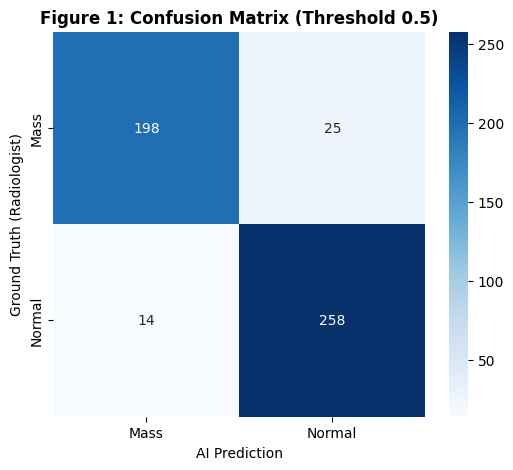

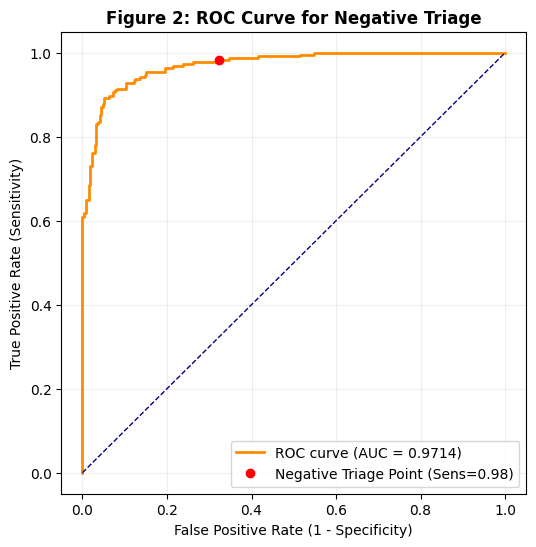

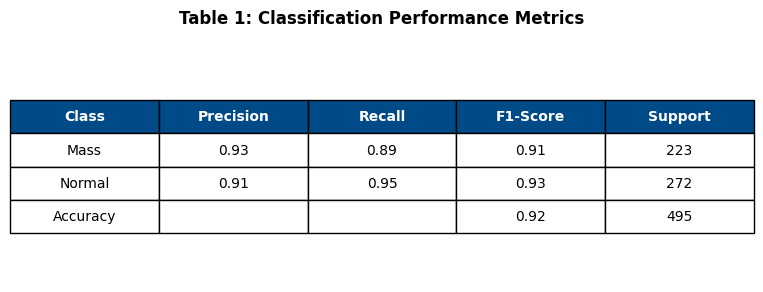

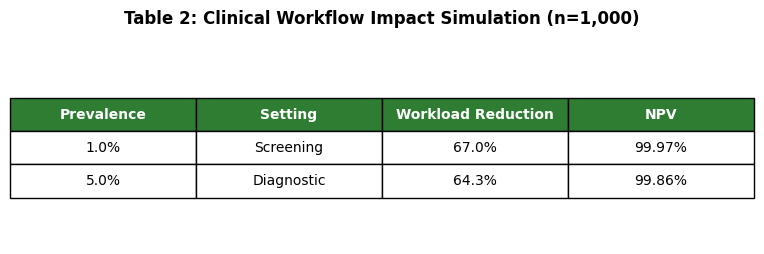


📥 Downloading all manuscript-ready figures...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# 1. EXTRAÇÃO DOS DADOS DE VALIDAÇÃO
def extrair_dados_para_exportar(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []
    all_probs = []

    print("🔄 Coletando predições para exportação...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            # Predições (0 ou 1)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

            # Probabilidades (da classe Mass/Nódulo)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            all_probs.extend(probs[:, 0].cpu().numpy())

    return y_true, y_pred, all_probs

# 2. EXECUÇÃO DA EXTRAÇÃO E CHAMADA DA FUNÇÃO DE EXPORTAÇÃO
# Certifique-se de que o 'model_ft' e 'val_loader' já foram carregados
y_true_vals, y_pred_vals, prob_vals = extrair_dados_para_exportar(model_ft, val_loader)

# Chamada da função que gera os gráficos e tabelas em inglês
export_manuscript_figures(y_true_vals, y_pred_vals, prob_vals)